# 02 - HOLIMO Observation Baseline
Derived from `notebooks/prior_versions/plume_path_plot_clean.ipynb`.\n

In [1]:
import os, platform, socket

def is_server() -> bool:
    # strong signals
    if os.getenv("JUPYTERHUB_API_URL") or os.getenv("JUPYTERHUB_USER"):
        return True
    if os.getenv("SLURM_JOB_ID"):
        return True

    # fallback heuristic (common: local macOS, server Linux)
    return platform.system() != "Darwin"

print("system:", platform.system(), platform.release())
print("hostname:", socket.gethostname())
print("is_server:", is_server())

system: Linux 4.18.0-553.104.1.el8_10.x86_64
hostname: levante6.lvt.dkrz.de
is_server: True


In [2]:
from __future__ import annotations

import re, sys
from pathlib import Path
import colormaps as pcmaps
import matplotlib.axes as maxes
import matplotlib.dates as md
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from matplotlib.colors import LogNorm, ListedColormap
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import FixedLocator, LogLocator, FuncFormatter



xr.set_options(keep_attrs=True)

sys.path.insert(0, str((Path.cwd() / ".." / "src").resolve()))
from utilities import make_pastel, load_plume_path_runs
from utilities.holimo_helpers import load_and_prepare_holimo

def create_new_jet3(n_colors=256, n_ice_colors=32):
    ice_colors = pcmaps.ice(np.linspace(1, 0.5, n_ice_colors))
    bk_colors  = pcmaps.BkBlAqGrYeOrReViWh200(np.linspace(0.1, 0.9, n_colors))
    transition = np.linspace(ice_colors[-1], bk_colors[0], 16)[1:-1]
    return ListedColormap(np.vstack([ice_colors, transition, bk_colors]))

new_jet4 = create_new_jet3(1024)

new_jet3 = create_new_jet3()
new_jet3_soft = make_pastel(new_jet3, desaturation=0.25, darken=0.90)


In [3]:

holimo_file      = '../data/observations/holimo_data/CL_20230125_1000_1140_SM058_SM060_ts1.nc'

time_window_holimo = (np.datetime64('2023-01-25T10:10:00'), np.datetime64('2023-01-25T12:00:00'))
time_frames_plume = [   
                    [ np.datetime64('2023-01-25T10:55:00'), np.datetime64('2023-01-25T11:10:00')   ],
                    [ np.datetime64('2023-01-25T10:35:00'), np.datetime64('2023-01-25T10:50:00')   ],
                    [ np.datetime64('2023-01-25T11:24:00'), np.datetime64('2023-01-25T11:39:00')   ],
                    ]

obs_ids = [
    "SM059", 
    "SM058", 
    "SM060"
    ]
growth_times_min = [
    6.1, 
    8.0, 
    9.1,
    ]
seeding_start_times = [
    np.datetime64('2023-01-25T10:50:00'),
    np.datetime64('2023-01-25T10:28:00'),
    np.datetime64('2023-01-25T11:15:00'),
]




ds_holimo, lbb, cbb = load_and_prepare_holimo(holimo_file)
ds_holimo = ds_holimo.sel(time=slice(*time_window_holimo))
ds_holimo = ds_holimo.assign_coords({'diameter': ds_holimo.diameter * 1e6})
ds_hd10   = ds_holimo.resample(time='10s').mean()


# Optional HOLIMO overlay: requires ds_hd10, obs_ids, time_frames_plume, growth_times_min.
holimo_ice_var = "Ice_Pristine_PSDnoNorm"
holimo_overlay_cfg = None
if all(name in globals() for name in ["ds_hd10", "obs_ids", "time_frames_plume", "growth_times_min"]):
    holimo_overlay_cfg = {
        "ds_hd10": ds_hd10,
        "obs_ids": obs_ids,
        "time_frames_plume": time_frames_plume,
        "growth_times_min": growth_times_min,
        "seeding_start_times": seeding_start_times,
        "var": holimo_ice_var,
        "threshold": 1e-10,
        "unit_factor": 1e3,
        "scatter_cmap": new_jet3,
        "line_alpha": 0.9,
        "line_width": 2.35,
        "marker_edgecolor": "black",
        "marker_edgewidth": 0.35,
        "marker_size": 7,
        "legend_loc": "upper right",
    }

In [4]:
from pathlib import Path
Path("output").mkdir(parents=True, exist_ok=True)

['Ice_PSDnoNorm', 'Ice_PSDMnoNormMajsiz', 'Ice_PSDlinNorm', 'Ice_PSDlinNormMajsiz', 'Ice_PSDlogNorm', 'Ice_PSDlogNormMajsiz', 'Ice_Pristine_PSDnoNorm', 'Ice_Pristine_PSDMnoNormMajsiz', 'Ice_Pristine_PSDlinNorm', 'Ice_Pristine_PSDlinNormMajsiz', 'Ice_Pristine_PSDlogNorm', 'Ice_Pristine_PSDlogNormMajsiz', 'Ice_Aggregate_PSDnoNorm', 'Ice_Aggregate_PSDMnoNormMajsiz', 'Ice_Aggregate_PSDlinNorm', 'Ice_Aggregate_PSDlinNormMajsiz', 'Ice_Aggregate_PSDlogNorm', 'Ice_Aggregate_PSDlogNormMajsiz', 'Water_PSDnoNorm', 'Water_PSDMnoNormMajsiz', 'Water_PSDlinNorm', 'Water_PSDlinNormMajsiz', 'Water_PSDlogNorm', 'Water_PSDlogNormMajsiz']


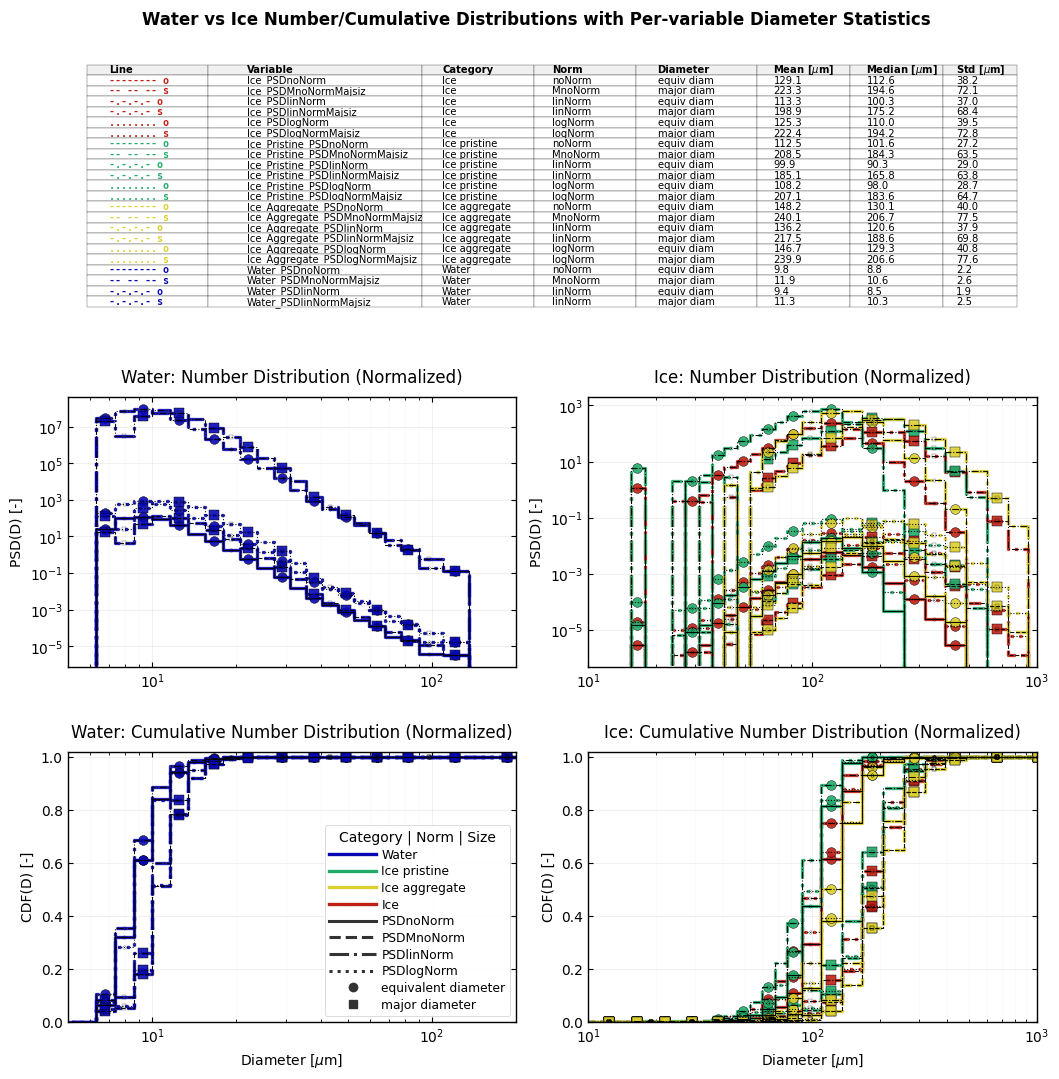

In [5]:
from matplotlib.lines import Line2D

phase_prefixes = ['Ice_', 'Ice_Pristine_', 'Ice_Aggregate_', 'Water_']
norm_keys = ['PSDnoNorm', 'PSDMnoNorm', 'PSDlinNorm', 'PSDlogNorm']
size_keys = ['', 'Majsiz']

valid_names = [
    f'{prefix}{norm}{size}'
    for prefix in phase_prefixes
    for norm in norm_keys
    for size in size_keys
    if f'{prefix}{norm}{size}' in ds_holimo.data_vars
]
valid_combos = [(norm, size) for norm in norm_keys for size in size_keys]
ds_hd10_frames = [ds_hd10[valid_names].sel(time=slice(t_lo, t_hi)) for t_lo, t_hi in time_frames_plume]


def _diam_stats(d, w):
    valid = np.isfinite(d) & np.isfinite(w) & (w > 0)
    if not valid.any():
        return np.nan, np.nan, np.nan
    d_v, w_v = d[valid], w[valid]
    w_sum = w_v.sum()
    mean_v = np.sum(w_v * d_v) / w_sum
    std_v = np.sqrt(np.sum(w_v * (d_v - mean_v) ** 2) / w_sum)
    median_v = np.interp(0.5, np.cumsum(w_v) / w_sum, d_v)
    return mean_v, median_v, std_v


def _plot_pair(
    ax,
    x,
    y,
    color,
    line_style,
    marker_style,
    line_width=1.6,
    marker_size=4.8,
    line_alpha=0.8,
    marker_edgecolor='black',
    marker_edgewidth=0.9,
    marker_every=2,
):
    ax.step(
        x,
        y,
        color=color,
        linestyle=line_style,
        where='mid',
        marker=marker_style,
        markevery=marker_every,
        ms=marker_size,
        lw=line_width,
        alpha=line_alpha,
        markerfacecolor=color,
        markeredgecolor=marker_edgecolor,
        markeredgewidth=marker_edgewidth,
        zorder=2,
    )
    ax.step(
        x,
        y,
        color='black',
        linestyle=line_style,
        where='mid',
        marker=marker_style,
        markevery=max(1, marker_every + 1),
        ms=marker_size / 3,
        lw=line_width / 3,
        alpha=0.95,
        markerfacecolor='none',
        markeredgecolor='black',
        markeredgewidth=max(0.2, marker_edgewidth / 2),
        zorder=3,
    )


fig = plt.figure(figsize=(12.5, 12.5))
gs = fig.add_gridspec(nrows=3, ncols=2, height_ratios=[2.8, 3.0, 3.0], hspace=0.32, wspace=0.16)
ax_tbl = fig.add_subplot(gs[0, :])
ax00, ax01 = fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1])
ax10, ax11 = fig.add_subplot(gs[2, 0]), fig.add_subplot(gs[2, 1])

base_cmap = globals().get('new_jet3_soft', plt.cm.viridis)
category_map = [
    ('Water_', 'Water'),
    ('Ice_Pristine_', 'Ice pristine'),
    ('Ice_Aggregate_', 'Ice aggregate'),
    ('Ice_', 'Ice'),
]
norm_styles = {'PSDnoNorm': '-', 'PSDMnoNorm': '--', 'PSDlinNorm': '-.', 'PSDlogNorm': ':'}
size_markers = {'': 'o', 'Majsiz': 's'}
size_labels = {'': 'equiv diam', 'Majsiz': 'major diam'}
style_tokens = {'-': '--------', '--': '-- -- --', '-.': '-.-.-.-', ':': '........'}

category_order = [label for _, label in category_map]
category_colors = {label: base_cmap(pos) for label, pos in zip(category_order, np.linspace(0.18, 0.82, len(category_order)))}

rows = []
plot_vars = [var for var in valid_names if var in ds_holimo.data_vars]
print(plot_vars)
for var in plot_vars:
    category = next((label for prefix, label in category_map if var.startswith(prefix)), None)
    norm_key = next((key for key in norm_styles if key in var), None)
    size_key = 'Majsiz' if var.endswith('Majsiz') else ''
    if category is None or norm_key is None:
        continue

    dist = ds_holimo[var].mean('time')
    cdf = dist.cumsum('diameter') / dist.sum('diameter')
    mean_v, median_v, std_v = _diam_stats(dist.diameter.values, np.asarray(dist.values, dtype=float))
    ls, mk = norm_styles[norm_key], size_markers[size_key]
    rows.append([
        f"{style_tokens[ls]} {mk}",
        var,
        category,
        norm_key.replace('PSD', ''),
        size_labels[size_key],
        f'{mean_v:.1f}',
        f'{median_v:.1f}',
        f'{std_v:.1f}',
    ])

    ax_psd, ax_cdf = (ax00, ax10) if category == 'Water' else (ax01, ax11)

    important_plot_kwargs = {
        'line_style': ls,
        'marker_style': mk,
        'line_width': holimo_overlay_cfg.get('line_width', 2.0),
        'line_alpha': holimo_overlay_cfg.get('line_alpha', 0.8),
        'marker_size': holimo_overlay_cfg.get('marker_size', 6.5),
        'marker_edgecolor': holimo_overlay_cfg.get('marker_edgecolor', 'black'),
        'marker_edgewidth': holimo_overlay_cfg.get('marker_edgewidth', 0.35),
    }
    _plot_pair(ax_psd, dist.diameter, dist, category_colors[category], **important_plot_kwargs)
    _plot_pair(ax_cdf, dist.diameter, cdf, category_colors[category], **important_plot_kwargs)


ax_tbl.axis('off')
show_rows = rows[:22]
col_labels = ['Line', 'Variable', 'Category', 'Norm', 'Diameter', 'Mean [$\mu$m]', 'Median [$\mu$m]', 'Std [$\mu$m]']
tbl = ax_tbl.table(
    cellText=show_rows,
    colLabels=col_labels,
    loc='center',
    cellLoc='left',
    colLoc='left',
    colWidths=[0.13, 0.23, 0.12, 0.11, 0.13, 0.10, 0.10, 0.08],
    bbox=[0.02, 0.02, 0.96, 0.96],
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(7.2)
tbl.scale(1.12, 1.85)
for (r, c), cell in tbl.get_celld().items():
    cell.set_linewidth(0.2)
    cell.PAD = 0.18
    cell.set_height(cell.get_height() * 1.3)
    if r == 0:
        cell.set_text_props(weight='bold')
        cell.set_facecolor((0.94, 0.94, 0.94, 1.0))
    elif c == 0:
        cell.set_text_props(color=category_colors[show_rows[r - 1][2]], fontfamily='monospace', weight='bold')

cat_h = [Line2D([0], [0], color=category_colors[label], lw=2.4, label=label) for label in category_order]
norm_h = [Line2D([0], [0], color='0.2', lw=2.2, linestyle=style, label=key) for key, style in norm_styles.items()]
size_h = [
    Line2D([0], [0], color='0.2', lw=0, marker=marker, ms=6, label=('major diameter' if key == 'Majsiz' else 'equivalent diameter'))
    for key, marker in size_markers.items()
]
leg = ax10.legend(
    handles=cat_h + norm_h + size_h,
    labels=[h.get_label() for h in cat_h + norm_h + size_h],
    title='Category | Norm | Size',
    loc='lower right',
    frameon=True,
    framealpha=0.95,
    fontsize=8.8,
    title_fontsize=10,
    ncol=1,
    handlelength=3.8,
    handletextpad=0.45,
    borderpad=0.38,
    labelspacing=0.3,
)
leg.get_frame().set_linewidth(0.5)

for ax in (ax00, ax01):
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('')
    ax.set_ylabel('PSD(D) [-]')
    ax.grid(which='major', alpha=0.18, lw=0.8)
    ax.grid(which='minor', alpha=0.08, lw=0.5)
    ax.tick_params(axis='both', which='both', direction='in', top=True, right=True)

for ax in (ax10, ax11):
    ax.set_xscale('log')
    ax.set_ylim(0, 1.02)
    ax.set_xlabel('Diameter [$\mu$m]')
    ax.set_ylabel('CDF(D) [-]')
    ax.grid(which='major', alpha=0.18, lw=0.8)
    ax.grid(which='minor', alpha=0.08, lw=0.5)
    ax.tick_params(axis='both', which='both', direction='in', top=True, right=True)

ax00.set_xlim(5e0, 2e2)
ax10.set_xlim(5e0, 2e2)
ax01.set_xlim(1e1, 1e3)
ax11.set_xlim(1e1, 1e3)
ax00.set_title('Water: Number Distribution (Normalized)', pad=10)
ax01.set_title('Ice: Number Distribution (Normalized)', pad=10)
ax10.set_title('Water: Cumulative Number Distribution (Normalized)', pad=10)
ax11.set_title('Ice: Cumulative Number Distribution (Normalized)', pad=10)
for ax in (ax00, ax01, ax10, ax11):
    for spine in ax.spines.values():
        spine.set_linewidth(1.0)

fig.suptitle('Water vs Ice Number/Cumulative Distributions with Per-variable Diameter Statistics', y=0.92, fontsize=12, fontweight='semibold')
fig.savefig('output/figure12_holimo_water_ice_variable_comparison.png', dpi=300, bbox_inches='tight')

## Figure caption

**Figure 12.** HOLIMO water-versus-ice variable comparison highlighting differences in characteristic particle size and distribution amplitude across the available PSD definitions. The top row shows normalized particle size distributions (PSD), and the bottom row shows the corresponding cumulative distributions (CDF). Left panels summarize water variables and right panels summarize ice variables, enabling direct comparison of modal diameter, spectral width, and relative magnitude between variable formulations.

## Consistency check: pristine + aggregate equals total (HOLIMO ice PSD)

This quick diagnostic verifies that HOLIMO ice PSD totals are internally consistent:

- `Ice_Pristine_PSD* + Ice_Aggregate_PSD* == Ice_PSD*`

Small non-zero differences are expected from floating-point rounding.

In [ ]:
# If ds_holimo is already loaded in the notebook, reuse it.
# Otherwise load the same HOLIMO source file used in plume-path workflows.
if 'ds_holimo' in globals():
    _ds = ds_holimo
else:
    holimo_file = '../data/observations/holimo_data/CL_20230125_1000_1140_SM058_SM060_ts1.nc'
    _ds = xr.open_dataset(holimo_file)

triples = [
    ('Ice_Pristine_PSDnoNorm', 'Ice_Aggregate_PSDnoNorm', 'Ice_PSDnoNorm'),
    ('Ice_Pristine_PSDlinNorm', 'Ice_Aggregate_PSDlinNorm', 'Ice_PSDlinNorm'),
    ('Ice_Pristine_PSDlogNorm', 'Ice_Aggregate_PSDlogNorm', 'Ice_PSDlogNorm'),
    ('Ice_Pristine_PSDMnoNormMajsiz', 'Ice_Aggregate_PSDMnoNormMajsiz', 'Ice_PSDMnoNormMajsiz'),
    ('Ice_Pristine_PSDlinNormMajsiz', 'Ice_Aggregate_PSDlinNormMajsiz', 'Ice_PSDlinNormMajsiz'),
    ('Ice_Pristine_PSDlogNormMajsiz', 'Ice_Aggregate_PSDlogNormMajsiz', 'Ice_PSDlogNormMajsiz'),
]

rows = []
for pristine_name, aggregate_name, total_name in triples:
    if not all(v in _ds.data_vars for v in (pristine_name, aggregate_name, total_name)):
        rows.append((total_name, np.nan, np.nan, np.nan, np.nan, 'missing variable(s)'))
        continue

    diff = (_ds[pristine_name] + _ds[aggregate_name]) - _ds[total_name]
    vals = np.abs(diff.values)
    vals = vals[np.isfinite(vals)]

    if vals.size == 0:
        rows.append((total_name, np.nan, np.nan, np.nan, np.nan, 'no finite values'))
        continue

    ref = np.abs(_ds[total_name].values)
    ref = ref[np.isfinite(ref)]
    ref_mean = float(ref.mean()) if ref.size else np.nan

    max_abs = float(vals.max())
    mean_abs = float(vals.mean())
    p99_abs = float(np.nanpercentile(vals, 99))
    frac_exact_zero = float(np.mean(vals == 0))
    rel_max = float(max_abs / ref_mean) if np.isfinite(ref_mean) and ref_mean > 0 else np.nan

    rows.append((total_name, max_abs, mean_abs, p99_abs, rel_max, f'exact-zero fraction={frac_exact_zero:.6f}'))

print('HOLIMO consistency check: Ice_Pristine + Ice_Aggregate vs Ice_Total')
print('metric columns: max_abs_diff, mean_abs_diff, p99_abs_diff, max_abs_diff/ref_mean')
for name, max_abs, mean_abs, p99_abs, rel_max, note in rows:
    print(f'- {name:26s}  max={max_abs:.3e}  mean={mean_abs:.3e}  p99={p99_abs:.3e}  rel_max={rel_max:.3e}  [{note}]')

print('\nInterpretation: Difference in values close to machine precision.')

HOLIMO consistency check: Ice_Pristine + Ice_Aggregate vs Ice_Total
metric columns: max_abs_diff, mean_abs_diff, p99_abs_diff, max_abs_diff/ref_mean
- Ice_PSDnoNorm               max=1.110e-16  mean=4.319e-20  p99=0.000e+00  rel_max=2.404e-13  [exact-zero fraction=0.997013]
- Ice_PSDlinNorm              max=7.276e-12  mean=7.664e-15  p99=0.000e+00  rel_max=3.532e-13  [exact-zero fraction=0.992953]
- Ice_PSDlogNorm              max=8.882e-16  mean=9.333e-19  p99=0.000e+00  rel_max=3.819e-13  [exact-zero fraction=0.991242]
- Ice_PSDMnoNormMajsiz        max=1.110e-16  mean=5.553e-20  p99=0.000e+00  rel_max=2.404e-13  [exact-zero fraction=0.995336]
- Ice_PSDlinNormMajsiz        max=3.638e-12  mean=4.362e-15  p99=0.000e+00  rel_max=3.305e-13  [exact-zero fraction=0.990570]
- Ice_PSDlogNormMajsiz        max=4.441e-16  mean=8.676e-19  p99=1.388e-17  rel_max=2.036e-13  [exact-zero fraction=0.988557]

Interpretation: values close to machine precision indicate the identity holds numerically.


## Precision sensitivity check (float64 vs float32 vs float16)

This table compares numerical residuals of
`Ice_Pristine + Ice_Aggregate - Ice_Total`
under different floating-point precisions.

Note: some HOLIMO variables can appear with different dimension order (for example `('time','diameter')` vs `('diameter','time')`) depending on prior notebook operations. The script aligns arrays by dimension labels (`xarray.transpose` + `xarray.align`) before subtraction, so no manual `.T` is needed.

In [12]:
# Compare residual sensitivity across dtypes.
# Note: many NetCDF variables are stored as float64; this emulates downstream casting effects.

dtype_options = [np.float64, np.float32, np.float16]

if 'ds_holimo' in globals():
    _ds = ds_holimo
else:
    holimo_file = '../data/observations/holimo_data/CL_20230125_1000_1140_SM058_SM060_ts1.nc'
    _ds = xr.open_dataset(holimo_file)

triples = [
    ('Ice_Pristine_PSDnoNorm', 'Ice_Aggregate_PSDnoNorm', 'Ice_PSDnoNorm'),
    ('Ice_Pristine_PSDlinNorm', 'Ice_Aggregate_PSDlinNorm', 'Ice_PSDlinNorm'),
    ('Ice_Pristine_PSDlogNorm', 'Ice_Aggregate_PSDlogNorm', 'Ice_PSDlogNorm'),
    ('Ice_Pristine_PSDMnoNormMajsiz', 'Ice_Aggregate_PSDMnoNormMajsiz', 'Ice_PSDMnoNormMajsiz'),
    ('Ice_Pristine_PSDlinNormMajsiz', 'Ice_Aggregate_PSDlinNormMajsiz', 'Ice_PSDlinNormMajsiz'),
    ('Ice_Pristine_PSDlogNormMajsiz', 'Ice_Aggregate_PSDlogNormMajsiz', 'Ice_PSDlogNormMajsiz'),
]

print('| variable | dtype | max_abs_diff | mean_abs_diff | p99_abs_diff | max_abs_diff/ref_mean |')
print('|---|---:|---:|---:|---:|---:|')

for pristine_name, aggregate_name, total_name in triples:
    if not all(v in _ds.data_vars for v in (pristine_name, aggregate_name, total_name)):
        for dt in dtype_options:
            print(f'| {total_name} | {np.dtype(dt).name} | missing | missing | missing | missing |')
        continue

    # Align by dimension labels to avoid manual transposes.
    a_da = _ds[pristine_name]
    b_da = _ds[aggregate_name]
    c_da = _ds[total_name]

    # Reorder to match total's dimension order, then align coordinates.
    a_da = a_da.transpose(*c_da.dims)
    b_da = b_da.transpose(*c_da.dims)
    a_da, b_da, c_da = xr.align(a_da, b_da, c_da, join='exact')

    for dt in dtype_options:
        a = a_da.values.astype(dt, copy=False)
        b = b_da.values.astype(dt, copy=False)
        c = c_da.values.astype(dt, copy=False)

        # Compute in selected precision, then evaluate in float64 for stable summary stats.
        diff = (a + b - c).astype(np.float64, copy=False)
        vals = np.abs(diff)
        vals = vals[np.isfinite(vals)]

        ref = np.abs(c.astype(np.float64, copy=False))
        ref = ref[np.isfinite(ref)]

        if vals.size == 0 or ref.size == 0:
            print(f'| {total_name} | {np.dtype(dt).name} | nan | nan | nan | nan |')
            continue

        max_abs = float(vals.max())
        mean_abs = float(vals.mean())
        p99_abs = float(np.nanpercentile(vals, 99))
        ref_mean = float(ref.mean())
        rel_max = float(max_abs / ref_mean) if ref_mean > 0 else np.nan

        print(f'| {total_name} | {np.dtype(dt).name} | {max_abs:.3e} | {mean_abs:.3e} | {p99_abs:.3e} | {rel_max:.3e} |')
print('\nInterpretation: larger residuals in lower precision are expected; compare magnitudes to your target signal range.')

| variable | dtype | max_abs_diff | mean_abs_diff | p99_abs_diff | max_abs_diff/ref_mean |
|---|---:|---:|---:|---:|---:|
| Ice_PSDnoNorm | float64 | 1.110e-16 | 4.319e-20 | 0.000e+00 | 2.404e-13 |
| Ice_PSDnoNorm | float32 | 5.960e-08 | 6.582e-11 | 0.000e+00 | 1.291e-04 |
| Ice_PSDnoNorm | float16 | 2.441e-04 | 2.893e-07 | 0.000e+00 | 5.286e-01 |
| Ice_PSDlinNorm | float64 | 7.276e-12 | 7.664e-15 | 0.000e+00 | 3.532e-13 |
| Ice_PSDlinNorm | float32 | 3.906e-03 | 1.997e-06 | 0.000e+00 | 1.896e-04 |
| Ice_PSDlinNorm | float16 | 3.200e+01 | 1.433e-02 | 0.000e+00 | 1.553e+00 |
| Ice_PSDlogNorm | float64 | 8.882e-16 | 9.333e-19 | 0.000e+00 | 3.819e-13 |
| Ice_PSDlogNorm | float32 | 2.384e-07 | 2.420e-10 | 0.000e+00 | 1.025e-04 |
| Ice_PSDlogNorm | float16 | 3.906e-03 | 2.046e-06 | 0.000e+00 | 1.679e+00 |
| Ice_PSDMnoNormMajsiz | float64 | 1.110e-16 | 5.553e-20 | 0.000e+00 | 2.404e-13 |
| Ice_PSDMnoNormMajsiz | float32 | 5.960e-08 | 8.288e-11 | 0.000e+00 | 1.291e-04 |
| Ice_PSDMnoNormMajsiz